In [1]:
#here are the packages I used to do this. Feel free to add to this as needed
import astropy.units as u
from astropy.io import fits
import astropy.io
import numpy as np
from matplotlib import pyplot as plt
import scipy.integrate
import scipy
import pandas as pd

In [2]:
#Constants
R_sun = 6.95700E8 #m
parsec = 3.0857E+16 #m


#1 mJ * 10^3 J/mJ 


In [3]:
phot_stars_path = 'photometric_datav3.csv'#'photometric_testv2.csv'
photometry_path = 'photometry.csv'

phot_data = pd.read_csv(photometry_path)
star_data = pd.read_csv(phot_stars_path)
print(phot_data.columns.to_list())
print(star_data.columns.to_list())

print('----------------------------stars------------------------------')
print(star_data['star'])
print('----------------------------filter------------------------------')
print(phot_data['Filter'])

star_list = list(np.array(star_data['star'], dtype = str))
filter_list = list(np.array(phot_data['Filter'], dtype = str))

['Filter', 'wav_ref', 'wav_mean', 'wav_eff', 'wav_min', 'wav_max', 'Weff', 'ZP (Vega)']
['star', '2MASS ID', 'Gaia DR3 ID', 'AllWISE ID', 'GALEX ID', 'ra', 'dec', 'distance', 'vsini', 'VSX Period', 'Av', 'fe_h', 'm_G', 'Gaia G flux_over_error', 'm_BP', 'Gaia BP flux_over_error', 'm_RP', 'Gaia RP flux_over_error', '2MASS J', '2MASS J error', '2MASS H', '2MASS H error', '2MASS K', '2MASS K error', 'WISE W1', 'WISE W1 error', 'WISE W2', 'WISE W2 error', 'WISE W3', 'WISE W3 error', 'WISE W4', 'WISE W4 error', 'GALEX FUV', 'GALEX FUV Error', 'GALEX NUV', 'GALEX NUV Error', 'Li Profile', 'H-alpha Profile', 'Ca II H Profile', 'Ca II K Profile', '2MASS_qph', 'ALLWISE_ccf', 'ALLWISE_qph', 'leiner_class', 'updated_class']
----------------------------stars------------------------------
0                        HR Cet
1                        DG Ari
2          CSS J032403.3+152821
3       ZTF J035347.19+235007.6
4                   [WM2007] 85
                 ...           
1890       CSS J210416

In [46]:
star = 'HD 57267'

path = r'C:\Users\astro\SSG_Spectra\SSG_SEDs\SED_Models\\'
spec_file = 'ckp00\ckp00_4500.fits'
filt_path = r'C:\Users\astro\SSG_Spectra\SSG_SEDs\\'
R_star = 5.7621 #5.1 #5.7621
c = 2.9979245e8 #/s


UV_data = True

In [47]:
star_index = star_list.index(star)
Av = star_data['Av'][star_index]
dist = star_data['distance'][star_index]


In [48]:
#redening functions
a_IR = lambda x: 0.574 * x**1.61
b_IR = lambda x: -0.527 * x**1.61

def a_opt(x):
    y = x - 1.82
    a = (1 + 0.17699*y - 0.50447* (y**2) - 0.02427* (y**3)
         + 0.72085* (y**4) + 0.01979* (y**5) - 0.77530* (y**6) 
         + 0.32999* (y**7))
    return a
def b_opt(x):
    y = x - 1.82
    b = (1.41338*y + 2.28305*(y**2) + 1.07233*(y**3) 
         - 5.38434*(y**4) - 0.62251*(y**5) 
         + 5.30260*(y**6) - 2.09002*(y**7))
    return b

a_uv1 = lambda x: 1.752 - 0.316*x - 0.104/((x - 4.67)**2 + 0.341)
a_uv2 = lambda x: a_uv1(x) - 0.04473*(x - 5.9)**2 - 0.009779*(x - 5.9)**3

b_uv1 = lambda x: -3.090 + 1.825*x + 1.206/((x - 4.62)**2 + 0.263)
b_uv2 = lambda x: b_uv1(x) + 0.2130*(x - 5.9)**2 + 0.1207*(x - 5.9)**3

a_farUV = lambda x: -1.073 - 0.628*(x - 8) + 0.137*(x - 8)**2- 0.070*(x - 8)**3
b_farUV = lambda x: 13.670 + 4.257*(x - 8) - 0.420*(x - 8)**2 + 0.374*(x - 8)**3


def red(wav, Av):
    x = 1/(wav) * 1e-6/1e-10
    Rv = 3.1#Av/E_BV
    condlist = [((x >= 0.3) & (x < 1.1)), 
                ((x >= 1.1) & (x < 3.3)),
               ((x >= 3.3) & (x < 5.9)),
               ((x >= 5.9) & (x <= 8)),
               ((x >= 8) & (x <= 10))]
    functlistA = [a_IR, a_opt, a_uv1, a_uv2, a_farUV, 0]
    functlistB = [b_IR, b_opt, b_uv1, b_uv2, b_farUV,0]

    a = np.piecewise(x, condlist, functlistA)
    b = np.piecewise(x, condlist, functlistB)
    
    A_lam = (a + b/Rv) * Av
    return A_lam

In [49]:
modeling_data = phot_data[0:-1][['Filter', 'wav_eff']]

filter_files = np.array([r'2MASS\2MASS_2MASS.J.dat', r'2MASS\2MASS_2MASS.H.dat', r'2MASS\2MASS_2MASS.Ks.dat',
               r'WISE\WISE_WISE.W1.dat', r'WISE\WISE_WISE.W2.dat',r'WISE\WISE_WISE.W3.dat',r'WISE\WISE_WISE.W4.dat',
               r'Gaia\GAIA_GAIA3.Gbp.dat', r'Gaia\GAIA_GAIA3.G.dat',r'Gaia\GAIA_GAIA3.Grp.dat',
               r'GALEX\GALEX_GALEX.FUV.dat', r'GALEX\GALEX_GALEX.NUV.dat'])

filter_names = np.array(modeling_data['Filter'])

ylabel_orient = ['bottom', 'top', 'top',
                 'top', 'top', 'top', 'top',
                 'top', 'bottom', 'bottom', 'top', 'top']
xlabel_orient = ['right', 'right', 'left',
                 'left', 'left', 'left', 'left',
                 'right', 'left', 'right', 'left', 'left']

In [50]:
def star_flux(mag, zero_point, m0=0):
    flux = 10**(-(mag - m0)/2.5) * zero_point
    return flux


def star_photometry(filt_name, return_err = False):
    '''
    returns
    
    '''
    #get filter
    filt_index = filter_list.index(filt_name)
    
    #gather ZP
    ZP = float(phot_data['ZP (Vega)'][filt_index])
    
    
    #flux
    
    #GALEX Filters
    if (filt_name == 'GALEX FUV') or (filt_name == 'GALEX NUV'):
        
        if filt_name == 'GALEX FUV':
            cts_factor = 1.40e-15
            m0 = 18.82
        else: 
            cts_factor = 2.06e-16
            m0 = 20.08
        
        filt_name2 = filt_name + ' Error'
        mag_ab = star_data[filt_name][star_index]
        mag_err = star_data[filt_name2][star_index]
            
        flux = star_flux(mag_ab, cts_factor, m0)
        flux_err = np.abs(star_flux(np.array([mag_ab - mag_err, mag_ab + mag_err]),
                                    cts_factor, m0) - np.array([flux,flux]))
    #GAIA FLUXES        
    else: 
        if (filt_name == 'Gaia BP') or (
            filt_name == 'Gaia G') or (filt_name == 'Gaia RP') :
                filt_name2 = filt_name + ' flux_over_error'   
                filt_name = 'm_' + filt_name[5:len(filt_name)]
                
                mag = star_data[filt_name][star_index]
                flux_err = star_data[filt_name2][star_index]
                flux = star_flux(mag, ZP, 0)
                flux_err = np.array([1/flux_err * flux, 1/flux_err * flux])
        #ALLWISE + 2MASS Fluxes      
        else:
            filt_name2 = filt_name + ' error'
            mag = star_data[filt_name][star_index]
            mag_err = star_data[filt_name2][star_index]
            flux = star_flux(mag, ZP, 0)
            flux_err = np.abs(star_flux(np.array([mag - mag_err, mag + mag_err]),
                                    ZP, 0) - np.array([flux,flux]))
    
    if return_err == True:
        return flux, flux_err
    else:
        return flux

def model_fluxes(model_file, logg):
    '''
    filter_file (str) - path of the filter transmission file
    model_file (str) - path of ATLAS9 model file
    logg (str) - surface gravity
    '''
    model_path = path + model_file
    model_data = fits.open(model_path)[1].data
    wav = model_data['WAVELENGTH']
    reddening = 10**-(red(wav, Av)/2.5)
    model_flux = model_data[logg]
    return wav, model_flux, reddening
    

def filter_transmission(filter_file, wav, model_flux, return_original = False):
    filter_file = filt_path + filter_file
    filt_data = np.genfromtxt(filter_file, dtype= float)
    filt_wav = np.array(filt_data[:,0], dtype = float)
    filt_flux = np.array(filt_data[:,1], dtype = float)
    
    print(len(filt_flux) == len(filt_wav))
    
    if return_original == True:
        return filt_wav, filt_flux
    else:
        filt_interflux = np.interp(wav, filt_wav, filt_flux) 
        return filt_interflux
    
    
def model_filt_flux(filt_name, filter_file, wav, flux, inter_wav = -1, inter_flux = -1, rad = 1, interred = -1):
    filt_index = filter_list.index(filt_name)
    #gather wav_eff, Weff
    cent_wav = float(phot_data['wav_eff'][filt_index])
    W_eff = float(phot_data['Weff'][filt_index])
    
    #check for interpolated function
    if (type(inter_wav) == int) or (type(inter_flux)  == int):
        inter_wav = wav
        inter_flux = flux
        
    #gather filter transmission data
    filter_file = filt_path + filter_file
    filt_data = np.genfromtxt(filter_file, dtype= float)
    filt_wav = np.array(filt_data[:,0], dtype = float)
    filt_flux = np.array(filt_data[:,1], dtype = float)
    
    #Normalize
    div = 1
    if max(filt_flux > 1):
        div = max(filt_flux)
    
    filt_interflux = np.interp(wav, filt_wav, filt_flux)/div
    
    #calculate center
    filt = np.where((inter_wav >= cent_wav - rad) & (inter_wav <= cent_wav + rad))
    av_flux = scipy.integrate.trapezoid(filt_interflux, x = wav)/W_eff #find average flux
    
    #calculate redening
    if type(interred) == int:
        filter_red = 1
    else:
        #interred = np.interp(inter_wav, wav, red)
        filter_red = np.median(interred[filt])
    return av_flux * np.median(inter_flux[filt]) * filter_red


def get_flux_models(wavelength, model_flux, red):
    #interpolate
    int_wav = np.arange(min(wavelength), max(wavelength), 1)
    int_model_flux = np.interp(int_wav, wavelength, model_flux)
    int_red = np.interp(int_wav, wavelength, red)
    

    #Find Names
    temp_list = np.array(list(zip(filter_files, filter_names)))
    flux_list = np.array([model_filt_flux(item[1], item[0], wav = wavelength, flux = model_flux,
                                              inter_wav = int_wav, inter_flux = int_model_flux, 
                                               interred = int_red) for item in temp_list])
    return flux_list
        

In [51]:
#get photometry files
wavelength, model_flux, reddening = model_fluxes('ckp00\ckp00_4500.fits', 'g40')
wavelength5000, model_flux5000, red5000 = model_fluxes('ckp00\ckp00_5000.fits', 'g40')
wavelength5750, model_flux5750, red5750 = model_fluxes('ckp00\ckp00_4250.fits', 'g40')

print(len(wavelength), len(reddening))

λeffs = np.array(modeling_data['wav_eff'])
obs_fluxes = np.array([star_photometry(item, return_err = False) for item in filter_names])

1221 1221


In [52]:
mod_fluxes = get_flux_models(wavelength, model_flux, reddening)
print(1)
mod_fluxes5000 = get_flux_models(wavelength5000, model_flux5000, red5000)
print(2)
mod_fluxes5750 = get_flux_models(wavelength5750, model_flux5750, red5750)
print(3)

1
2
3



First, lets read in a stellar model of an A0 main sequence star. A fits file containing the model was provided with the lab ('ckm05_9500.fits'). This is a Castelli-Kurucz stellar model of an A0 main sequence star with [Fe/H]= -0.5. More information on the models can be found here: https://archive.stsci.edu/hlsps/reference-atlases/cdbs/grid/ck04models/AA_README

You should see that the file contains several different columns that correspond to a difference surface gravity (log g, where g is the gravitational acceleration at the surface of the star). We want to use log(g)= 4.0, so we will want to use the "g40" column for the analysis that follows.

Plot of this model SED (flux on the y axis, wavelength on the x axis). Scale both axes logarithmically. Include axis labels and don't forget units. You can find information on units in the table header and the documentation about Castelli-Kurucz models.

In [53]:
#UV_data = False

if UV_data == False:
    lim = 10
else:
    lim = len(mod_fluxes)

#R_star = 4.2#R_star #8#5.7621 #5.1 #5.7621
    



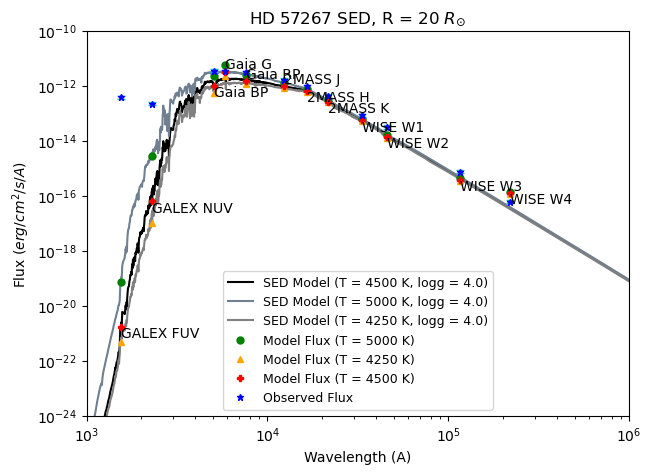

In [57]:
R_star = 20#4.5 #5.7621 

flux_scale = ((R_star * R_sun)/ (dist * parsec))**2 

fig, ax = plt.subplots(1, figsize = (7, 5))

#Models
ax.set_title(f'{star} SED, R = {R_star} ' + r'$R_{\odot}$')
#ax.plot(int_wav, int_model_flux * flux_scale, ls = '--', color = 'green')
ax.plot(wavelength, model_flux * flux_scale* reddening, color = 'black', label = 'SED Model (T = 4500 K, logg = 4.0)')
ax.plot(wavelength5000, model_flux5000 * flux_scale * red5000, color = 'slategrey', label = 'SED Model (T = 5000 K, logg = 4.0)')
ax.plot(wavelength5750, model_flux5750 * flux_scale * red5750, color = 'grey', label = 'SED Model (T = 4250 K, logg = 4.0)')

#ax.errorbar(λeffs, obs_fluxes , yerr = [obs_errs[1], obs_errs[0]], 
            #fmt = 'none', color = 'tab:blue', capsize=3, lw = 3)

#ax.plot(int_wav,int_model_flux, color = 'g', ls = '--')

ax.errorbar(λeffs, obs_fluxes , yerr = [obs_fluxes*0.1315, obs_fluxes*0.1315], 
            fmt = 'none', color = 'tab:cyan', capsize=3, lw = 3)


ax.plot(λeffs[0:lim], mod_fluxes5000[0:lim] * flux_scale, ls = 'none', marker = 'o', 
        ms = '5', color = 'green', label = 'Model Flux (T = 5000 K)')

ax.plot(λeffs[0:lim], mod_fluxes5750[0:lim] * flux_scale, ls = 'none', marker = '^', 
        ms = '5', color = 'orange', label = 'Model Flux (T = 4250 K)')

ax.plot(λeffs[0:lim], mod_fluxes[0:lim] *flux_scale, ls = 'none', marker = 'P', 
        ms = '5', color = 'red', label = 'Model Flux (T = 4500 K)')

ax.plot(λeffs[0:lim], obs_fluxes[0:lim], ls = 'none', marker = '*', 
        ms = '5', color = 'blue', label = 'Observed Flux')

for i in range(len(λeffs[0:lim])):
    ax.text(λeffs[i], mod_fluxes[i] * flux_scale, filter_names[i], va = ylabel_orient[i])

#,λeff_galexFUV
#ax.axvline(λeff_galexNUV, color = 'mediumvioletred', ls = '--')
    
    
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('Flux $(erg/cm^{2}/s/A)$')
ax.set_yscale('log')
ax.set_xscale('log')

ax.legend(fontsize=9)

ax.set_xlim(10**3, 10**6)
ax.set_ylim(10e-25, 10e-11)



fig.savefig(r'SED_images\\' + star + '_SED.png', dpi = 300)
#ax.set_ylim(10e-14, 10e-11)

#create synthetic observation #put error bars in
#Reddening (Leiner 2022)



In [13]:
print(flux_scale)

9.847973400076832e-19
